## 1. Importación de librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


## 2. Dataset incorporado

El archivo CSV de SO₂ de 2023 está incorporado dentro de este cuaderno. La siguiente celda reconstruye y carga automáticamente los 1,774 registros originales, por lo que no es necesario subir ningún archivo adicional. Todas las tablas, métricas y gráficas se generan directamente a partir de esta base.


In [2]:
# Dataset original de SO₂ de 2023 incorporado en el cuaderno
import base64
import gzip
import io

datos_comprimidos_b64 = '''H4sIAOrarGoC/+2dW3Mdx5Wl3+dXIPTUE1HiVN4znzogCrY4JgmZoNzTj7QESZyhCAcEqdv/fuqAsMVameckTgERFnOtCD+IEk1if5WXnXvty5dvbi6ni7c3lyfPvpy+Pn86ffnm7bu/n7x4898nF+f25OnV+28v399cv7l5e/V++ub925uf737H6Z+fnfzlzbtfLqfnV9++eXdy+2e8fPPT5d1/P//rz8v/+5f3N9PXl9e7P2P51U9/e3e5/HWnf744+frN9fJ7by6vl3/9Hf6rLy9//vb67d9u/84Xlzc/Xn334Xfd/fPH//npFxenH/7j7T/d/gC3P8rz5Ue++eW7f/zq6v0PH3755dVPb9+/WX6ci6tflp9rOnt3+eutdSf/9tP/XP6GNz//cn350+7nvVjMuqz/zfLXf/92AXH7w10t/3B1ffL673+7/Mcv3r7/4eT0h8v33/79439z/tf/e/ntzdtfL6eXp7fGXr/96c31AvrDb/n36eXlzX9dXf+/n6evr6/+enny1eXbH368uf2Z/nxa/e7/YWfrPp/N8r9pNnNy8/LryU7ztEC8+fnkbwvEv7599273M87Ty6vrmx9Pvnh7vVj+w49vfpqsn8w8T9765f9/8cu773+5Pvnu7dV/v1347P7Ds5cXr1998+Ls5evT5yefn3zz/PWr0788O39+9vrkD8+/OX91dvH07OXTs8m4bOfps9/+5M+/urr69fJ6Ojl9/tnk3JMQ3Bzi9HmOT7IJy/p69vL1ZFKaXp49++NXX5y/+ur8/MspzPPJi5PX5yf+Ty+mi+enLy6mz/735fffX17/vHyW20X0990febKg/9ti3+23OP9+YfTm3c2Pn03nr786ezVNL58uP9nypz8J02987JrPkyJCQMgBISdCQMgDoShCQCisCJkGH1PzMW4KngJPXON5ku4JqEypUABKK0C+eUpH6h2WYQm5+y0hIkIFTmmvU3pNyMwrQq5JyFMTWnvT9knrJnMNQmbKmQKQ1SbrEEJ32tyPkElTMhSAPNxkVjcZEFp707G5hAo1oQg3mdVNBoQSEDIiBISyrrIOobItdkbzbLXzluArDx6zzRXi2WHWKnp/kI8DXzHKVwRCXvd8hxDEppu3GPcaihvPaTsVSwEoAaCggxoIYXg6aJMBoaKD+jAhN0uI7hCSQ32QkK3SYUSoIoQRfHtPQvOUHQWgrfkwHN6QxXSY+4tkPHssKGGoQwgzYrL8RSCUgJARISCUJSR2CGEAP9/zHOJIZ7CYESN3sSYkh7pHyOrZ2iHkdFB3CHnFqDuENmWYE/GJmzLwOZLOLKbD6FFfAVIAv0do7UyH5hJKzIQwHebezw0eQkZVHB1CSjDvEVJ8ugPIS63vEAoi1CEUVTbeIZREqEMog06WpZN9TMihWu+bgaFITQjdoaRqsjUgZQj3CHnVSnUIBTiovQ5qIIT1dk5rCAglWENOawgIZahqtapqBUJlY3TITSUyADIKMPYIGTiokw5qILT2qK2OaeDjlLvYIaT4Yo8QOtThfruMpDLaoVrvm5usEfhYll7IDIBASry3O72AjYkCkNm2xXgOIVASXZOQp01+dSgk2uYh5GiFRIdComKLNaEgEahDCG/6IIkDCKVtEgcRIRQSi+56IFRgl/l77jKWux5q682e2GLryZGnFCgQmY27jCP66uvaekVfkZDdeAzxEAK5vp29aDzzNvMq/O0QCht1Mo4WFr6urvdaQkAI5XrpQEgoq+DuIJ8ipfUwIYMx/KQ9BoTWHnVpn9PciNYutfHNy95SPztM5VTH+zrVPIw2etUkkrSvCuxVmlgRigpUdwglRYg6hNZedWqX2XMjKpAnXO6ZJ8whS3vMjfHNcygyAzIbMz9o9lhVZa+DGgk5ZTZ0CGmOW49QUAFwh1BUAXCH0FaXmuay39q4ikUMgtwYBfKBTzV2Qs/6FaGAiR9SpGtCVoQ6hNxGSZrjHgtV2kf7xcEcxA+Y+FHad72jRqTGVT1CGqzQI5TlEXUIyac+yKdK/VB6FRLamExNokeHKvFDx3RFSCHqHiGvnIYOoaAS1w4hOdQ9Qlsdao6KjlDNVtAWAz5FavRhQpDyIWeoJmS0xw7ysepP2SHkNrZaZnmRWa96jg4hNRLuEYpqRt0hlPQi6xDKqm7tEFJ4+iAfN+uc7hAyGwP4HHJ9rEeXOGUuAiGrAukOIafecB1CHmqBomYGAKGgLPwOoajYWYeQMmJ6hPK20AfJGK6ICTGh6VEn5iUEKTGl/a531IiMnmUdQqrb7BFy8oc6hPym4BBHp9yIGTHK96gJyaHuEUqKUHcIZY0v6RAqOocOE7KzCHUIGZ1DHUJ2m7tIkvQRMStGS6gm5Dc2IOAhJJe6R0gudY9Q0ru+QyhDCDbeMwTLkYYf6yFBWXLrmhBOCVK91JpQqlqhiA/wsXIXO4ScVtBBPl7OYoeQUj56hKJe9YcBKeOjR6iIUIeQqloP8jGq2ewRwhzqqAcZELIbZ5JypOEn9UDpE1Kb7h6hoIO6Q0jh6R4hhad7hLJksg4hPTk6hKo2KOWe73qONPxUJ3xYtWJaA7LbVhDRHlN8+jAfr6LNDqEARZtBRZtAaOvYG5ZnPWR7uGZkyFMvoazq+g6homqyw4ScItQ9Qkbn0CFCue6DoqQqJLSxD4rJUwoUgNxGkYNnCWHnRSNCQCjAJjM6qIFQVPy1Qwhj+EmEgBA+Opx2GRAqG/ubcrzsc50Vo/amSMgoCb9DyOoq6xACl1ruIvDxOoU6hJRk3iOErcy9nCEglHQKHeSDFZv2fhWbJOkMGTNi7q+T0SyhKiNG9XZICAPUXmsICIE7nZr+tKW+yqo2KEnj69eANByoR2jtUesYQj5RIfwOoaScjw4htRXsESoawHWYkLJiuoTMxjR8jvL6gkkxSj2rCWFhaxQhIOTkDnUIeV1lHUKaR9ojFDfOueMhlDbmnnEMDChVHxSp0RWhIqXsMCHIinFNj5qbkFzqHiHIM9cKAj5OV32HkNcKOsgnqHi8Qygqr6pDSI1ieoRU2dojJH+6Q6hKi5FcD4CMKso6hKzyhjqEnKqBOoQgzbwdojaFmlFQAXmHECbGZO0zIJRUMtUhlLfV2JM0ISh1txg1IQBCkBejxmdrQmbGtA/XJOSpCWk8UI+QkzvUIeRVVXaQD0aps3rArgHFjYB4lpDGA/UIZYXxO4SKCoIOEzKz5MQOIaMIY4eQ5td3ADkd1B1CGhDUI6QBQT1CUUMDDvJJyhHuEMobM4coFPsdoKKwxyE+Vo0Fe4SM3hsdQlZZMR1CmETtRAgIee2yDqEgtb5DCOcDFc0HWgNKCnscBpQVfe0QKootHiZUNULROY2EjEJnhwgZTInRs74CZDVhqkPIqdqlQ2j95Igatwl84MGx5xSK1Izitl7URISSMoQ7hLJCHx1CZVvqGcm71WBOjFQO5KPhQD1CiuH3CLltsSGOWqAdIOxlnrWEgFBQL50OoaiDukNInVB6hNRZsEdIA4I6hCAtRh3xa0IK4vcI2W35rzQO4+bpQDxLyOsY6hAKUuw7hFS32SMkl7pHSHWbPUJlUxNYFr3ezepOeYiQrbugqF0VErKKDXUIOfWJ6RBSmnmPUJC72CG0NUbNcdlbTPnQhKmaUIYAbLpfAJZjhP0OUNFdf5iQ0bzNHqGthZsUI7h2gNYOdWxe9YV6CbmN3cxplpByPnqEgt5kHUJRhDqEFKDuEcryFzuEVLjZIQQ5H+KDfMzG8noeQhaqgdL9qoFI6hRsnfGh4CIS8nKGOoTkUPcIReVVdQiljcXRHM3ebZ3woU2GhMrG+Os8ZccAyKmzYI+QUVe4Q8OTfuuDsljllrWyr83HH968vf7+7eW77w6jyXl69v7nm+tfdj/Bm3cLmrNvr24uv/3x5OLy+u37X34+CXMfis8h3EEpC5Tlj50P8DgOxVfLH3N28frk6fnyfV4un+31s/OX07SY+BsSu0Kyb54UFRK3QjI3L6v5YyQHwvNjEPFAxPWIjL9IAhwlXkdJhFVStEoSrBKrVZJXSPY9BaiQFB2vgOQf6Sj/XCWWfpUYA0ickFidJYgEnVejswS8VwEJ8OaL9G8+s/ZdHb2bZhKcI0HbBj1X07ttDsRmxyCCjmumXyR2BiRJSIyOEkSCjmugd1yt0ypBJF6rBJGEY2Pz4yOJCpUgknSspzY+kizpE5Gsvdd9zdaZkDj0Xi398erW3qtt3jjuYyQH6rIHIGIxi+Iei2Tsd7DFJAr5rhaTKHQF2zqLwmqVhGMP1/GRRMl8iCTpHYxIMBadhaQoNABIjNz5ComRPo5IrJAgEgxGRyHxEC0J5NESi3kU+wouaBLFLaZRyFOzdSKF7mBIpNg3HIwKydp5NbZd3sZ1vla5FJl+61ij0wSRWJVrARGnRYJIFHutkASVayGSqFWCSJKySxBJVoR+hcRtkIQPdD4Zg4jTvkEkijNWSLw0C0QSdAcjEknCFZKkswSR5GOj0eMjUWE9IqkkYW0ckIT3TU+hQmIVeUUkKqyvkCioViEJx5Z/jp0t7lAStvROSSUI680HgrDOVleX1gsJysECosL6ColVaxtE4iAuUOiv4EoN1uGKarCAKJWxQqJUxgpJ1hWMSMqxeSWjP4Ghqt42FwnXDeyM6tdWSPyGHIrxkaDrmsk3jsckCisgSqGokAQ4XIsO16hVgkiSxHFEkvUIXgMpet4AEqMoNAAxasKPSOyxfuvYJUm+zp7Q/WsUhK6QBCFBJFFIEEnSrIY1kCypApEUxRcBCaRPaNKnxwQKbRxfV9MX+vvGqhlUhcQrPxyRQNBVJ0k8do2MrQP7On9CZ2uVP6EgdJU/oevGKeb6MZCgXIEGEqsIIyJRH6gKiVdcAJEE+fKIBHN/k1YJ9oGKQpJ14yCSolUCSMzRTUzHnpYU6hb8jn7fVP0WkpA4BUsQiddMLUQSlHyESJTXWSGJCqkhkqwbB5EUhUsACeQMsI98CXXLBW2bKmPAcet8oU4Y0A1cJQwISdV/X0iqnguW3ptXz4UaifrvV0iKgiWABHMG5Klh0wX2NIpYp1FkIbGKMSISRaIrJF6OGiIJyhlAJFEp0Wsg6dj7Zuy64FjnUCSdrUVIAAnkUEjli3UShVaJkihqJE5IEIkXEkQS1OUHkUQ9gxFJ0iWMSHDkWiJvxxjrJAodr3ZWlBGRGI1JAiJWsZI1EEVdKyTK/62QBK0SRKIkigpJUp8fRCLXtUJSAImlR+JmdRJfIUmYM6BncKpzBoKQOOWoIRKvVYJIwrEO/djP4FR3XtC+qTovCEmVNcBez5fqzgtaJVXWgC6cKmug0G8cYxUuQSTqG1Yh8QrPr4Go3S0AkedaIdFcggqJItEVkmMzBpadFtPIRKqEgQflYy3/4dnLi9evvnmx/HXLz/X5yTfPl7/2L8/On5+9PvnD82/OX51dLD/K07PfP5hHbXs7Epi1E/v5A3sRjkTGIRknMh/IPGpLhpHAHJ1TcKBj40hcoq6lNpj0mCGEkcBkGDmVHjJyaiQwRVupCabq2iAP7w6Mecxm08OAyVU+ho7eD1iOzCc+UGg8EhWnc7cN5lGHEY8EJjym1DwSmEetkBsJzKNOeRsJTJYL0wZTdFfXVKrBGYpP3YExcmLaYB61AcRIYJzAtMF4PR5bWIJu6jaYKN+uDSbrhGmDObp/M4l3V3TENMFYub17wDxqs96RwKzd3tiMxBRGME4rpg3Gy41pgzk22rtcY6kQcMlH7qTF7UmGgIt0/DYYbBzQeViTbCNnHnFU1jBcSj2HQVkfd2CsZNk2GKcV0wbjlYvYBrN27Vonr2fEEvVGaoNJClC1wWTdSW0wRalCTTBVIwbdSXdgjLZSG4yVLtvC4vR+bHLxCsO0wQSJSW0w8fFGYY6EJelZ3QYjp3cPmKIV0wSDOr6wfMBihKWFxWobtcE4eTBtMF7RhjaY8JgtlkYCE3XGtMEk7BFj1PHjFkxGMFoyd2Tk9rbBOPUua4AxM+Y4fK4n5D/JWD0JWliU4rAHjFdLtz1kou7rPWSCrqU2mMr3FZk7MlnHzB4yqt1qg6laFgjMHZhj5/0y1A/suFhFN9tgFPbdA0Zde/eACVJo22AU9t0DJmkrtcFk5Wu2wRT1vGuC0cSKfWDUq2sPGCswbTBqUbsHjD/WjyFIft5xkeO7B4wc3z1g0mOOsB8JDM6rKJpX8QGMHN82GKU77AOjPN8ai6k7XeiyvgNjFXNog3FKZ22DCVoxbTDYAiQKzAcwERolWjVK/ABm/SBwTTCeEUw+rg6dIeJg6vwPCScfwFT5H6rJuQOj10ATi9I/9oBx2khtMF4ZZm0w6nSxB0zUimmDSTpj2mDU62IPmKIhJ00wFhu8OUUcPoBRY+M9YI5ubMzxtK6yP3T23oHRgOI9YIIa+LbBRK2YNpgkzboNJuu2boPB9I8s/+4WDKR/2OaKcXRgbJ3nEDX28JaLIr57wDiFqdpgju1tzDBLacclyotpgwnK1WyDSZDdG5Xd+wFMVrf9FhbN82iDqdIcjJy7Wy5HTygm4YK5vUUnzAcwmNubenMy85QCARcvF6YNJiiPqoVFlX57wCTFwNtgsuIwbTBFb4EGlirDQVU4d2AMRMCLIuAfwNhjpQGGDAeLGQ7Skv4JRkPs9oAJ8u7aYJTauwdMUgVkG4xSe/eAKXpYN7BU7S2UXHYHxijxozH/5R8NLkqaD/cWevrVs6d/Or04/Y9p8QdLfDgX52JcuLy4Wv6OyzsY85OUZpPNAiM/mXNK0Uynr85Olz/4SUwHqFw8P31xMZ2+22G4BXD2/teTFz/cTF+ff/3N81urT87+z9fnF9+8Opv+c1o+9G/225X9+wIL49rvwH5LZr8H+wOZ/QHs92T2x5X9vpliMK71Cb5+Ivv6mfz2Kyv7U7snz8AL4ENqxG8LoPf5Hyfm97ux3nA7P8ZyOz/Gc1/+htz5Nej8FTL7I7f7YxL5+Z+5H3+mcH9/u/b+YvP7l4HtX/t/+5IBxrXfcvs/du3/uKZc4D+2/5Gi4r8bAEc7wKMBCMfeAKMBiMc+AUYDkI7cAmmyZRTzbe0Cm475xkw+DmQ/RkBdLwQ21Pq36APb5gJwAwMAJ/gej+DRABjqO9DWbjAdAOo4oK3dYDb7A3McxNZOsCezP5F/f+o4qMMkOLLv78iT4FydBBfJ7PfwBrJUbyCHWXCEACL1E8DVmXCBDQD6AJnsDCzcd6CZmd8Ars6FI1v/kAt3jytwMPsdBMItUyqww1xA17wA/cD2B/j+hez7x2OFoMHsT+T3Xyb3fwpzDNyhDNi//5YNk8xA9mMhbOA6/0AENGTWO2rrPffZbwP33W+p6yAcuf7n6PU/W5jroNxd2xhe/ctR67+eXP/2qH+TtQHwtf4dyL6/J1//1P6v36B+D2Z/Yr7/fa19s61/6tinr7XvRGY/xj4Nl/9T9YFh+/6O+/wzntv/rfrAkN3/VR8YNvsTc+6Tr4tgLdn9V47tAzGW/Zbc/6sqYMnu/6oAluz8B/X7HjXwg9nvedV/j+o3VQ9Uj9o327c/uuxlsK+Pnl8m+/6F++VbKd9U9oda+c1UZW+hLn1ObACOrn1+nCHovxv7wffbM9P7I/vnKbuB7KeO/YVa+/Vk9mdy+xO5B1C47TfkHmBV98xmP7X2G2rtl+z+N5657jeQzwAJG7Tfsd4/JpE/gKvCZzoAhbr1UajlX88GAOeABKr2Z6EWgMkuwaoBcuK6BFEA5ioACkdLwINZv3YBHVPyU0AJ2DaLX9zA9lM3PgwoAZM1fgooAZt29tPyTBqXwNr98033b9gp6BFFcP+kOwV+pCSYiBo43/fHMXiFyQOIGyTwwewPzOn/ESVwQ2Z9Yi5+jHUCAFXsI6IATvb1Qf5ms95wr31jj735Rkp+i1XTb7LV7498+Zs8pTCQ/YHc/nis5zPY7k/Uuz9TW1+Y2z3Hut032fe35J4fKN6lvf7dwAAc+QZYO3+pLXmPvAMC+QkQQfctTLpvRN2bbfvnY8c9jeX7V6p34fr+qHo3056HtT+h5kum+STUfFu7Pw1sPbXzl2rFl233B+acp1QXPVP5vqnSfMm+fiY//Qrz1zcz99c35J7f8ZrvYPY75lqPVA96psp2TLXqy7b+I/n3T8zKX6qbXXfPv6GKPVMt/UYyAJX2m9kAGG4XAMRfsn7Pqe53bcnsRxfQc7kAWO7cVr+We2JcAij+RrIdkKDkLTOVvKUN8u9g9pdjO56MZb+bmfueJyx5Jkt+ySh/k038yXXJs2E6/zMK4GTnX0YBvP8CMnFafpZh7D++8G2oEECu2/72AJTJ5YHMp254lqkL/3Jd+Mdmf6D++vj291x3PwhAlsx66lmnuVZ/HJf9VbPbzHXzW0NuvyVf//jyTVS9jnPd69ZSqb+5Un+4Yp+5mnhKJv9nFH9yG8DQBPKxl8BIHS/zhuq30RZAIT8DQACKzRBIGRZAQQWotAtg3cgELHUMvNR9byOTCFjqKkguT7hsKIMcDUA8tvPxaADSsY7QSINfCpZCkuVBFSyFDM07MI1rP8jA7onj+v6QBxCa+3/k708dDS11MWQks98z58EVVMJDc/2PvP8jsxpa6mJINvsz8+iTUqvhnsv+qhSSzX7DXAxd6krIxJQNVFANL1RNgAv53NeCUjjZ47cqgrRkmz+Rr/5Mbn9hnvxbMAuAqw2CmVEC5jr/dvZbYud3Z78jfvzv7PfEwd+d/YHc/kgc/N7Zz+z/7ezPxHOvd/YX4kKwxX4zE/u/O/sN9/1vsAlE6u3/kbJ/dgCYu0Ds7PfcFyB1K9yd/ZHc/kSc/bWzP5Off0d3wh2oDGixv1J/yQJAFruAmZ4ANNj3t9wBUFB/meS/nfXk4b+qDprt9Ivk3z+Rf//MHf49vgZ4LPurIvBCZj91+M9UI2BDM/5nRyZgoQje9orgR/L/DQrgoWl/Gvj7e+gB4JnyP3cAAnEF/M7+SNsKcWf9kY0g5ym7gazPzNlvppoCS1X6s9iPpc9cJx914fPOfgtXfyS7+kH7jj3PdzDrPffhz618m1r59kzKn6l6gHOlfpm67tmRrX9IfQztAzCOS8AyTwDb2W+4dwB1H/Cd/VD80m7/aAZ+AllPPAN0Z39g1n9MrX97MvsT+ffPx07CGOsNUOnfhusNVOnfPQ8gLz/6KObbKgLYif+ZXd3HQNbbY1OfB2r8urPfMT9/bN34kCr+bzEAODfX/zyw/ZF4BOTO/gTf35B9f3T+HJn95dj5H2PZX40BjFzfn3oM4M5+y33+QfhvbgY/RrZ/7f/NZNYHausj+d5nbnq9sz+Tf//CvPvdzP31HXPXw/mu7MWYVObln/Z7Pp89//Hq7c8308mLq/c3l7++effu6uTrd2/e33z2WECMy8sr5LMv3l7/9Pb9Dz+++enzr66ufr28vmPjnsxlOak+z/FJntPykc6fvXy9/MAvnn355fOzk4unp8/Pdn/fByi3dKYWka8WhmcXr0+eni9/6cvlZ9nBmabJfoTEApIgJA6QOCHxgCQejeRxBKTfEZIASLJWSQQkSUjSCsk+oZEKSYZVYulXyW09ilbJapUUQJKPRjLajWOMXDVEYuWqIRJ5rxUSr2cfIll7r66ZApG4kDzcex3uxgHvld4rMVmPPkRSdLgCEjsLCSIx4M7rLLH2wTG14ZCg71ror2DrwVFr9+nhctVs0EsYkUSdJohE3isAyQKyBlIkWAASNwsJIlHcdY3E1okUSUjkzldI1u78vk4zVEjW7rzJzSfO4sxRQQnaOohk7c7b9oA254newhaTKVJbJidbKFk3MSIpDz1OTJlSGQlJlWASyd9+ts6m0MapsimykDjYOEEbB1zYPSVEVEjkwFZIFI+ukCQhQSQQkU5Nqdx6LihFYfoVEKuYdIXE6CxBJFarBJE4IUEkXhsHkch7rZBEvYQRSRISRLL2Xu3R6tZYAXqHsjC75+pQFN4/Z5MKitMqWQNZ+yThSbshLxWStU9iQ1Mnd5ELSoTIqyeviXV1fX3UabL2SkJsbp1EtnXWMbXSHnjgqJiY+cHVFsMhAQc2sydnuVoU1iqpRGFHf+mAKGybrgnXYxhE4dQesky2c6LKQBGJ4moVEtUpAZCiCweQgCZs2/nRXEjQeW2ermTuK6jCunEcqsJbTpPRfDVQhbVGrBy1CknQGlkDSVojiGTtubrmM9hzISmAJB2NZLTbBmrsg2+qFolrnTjlDnwMxCuZogKyduVtW+xzMxcUrLE35IFXX9XYP9HWmeW7AhB83yQhUbssAJJV6IhI1s48vaLlMYnCxrbymbigGPTUyvGe2mhuCSRSlPZEC8e1UBy2uTHHt7kZDooK7CskQW0YEIki9BWSpI2DSCAg3U4GDmRQIJ2indNouG4dO+uIRSRG9RaIxD54LNtwq8SBwOXINT+P6RT75kxTIVl7sLl9vJLtnLUL21JzCheQ9OA7eLgLJz/4Dh5ulRQ4SrKOEqcJumskocofaD9yuJBYNexYA3Fy5xEJ+K57MirIoKy9V988SyIXEoi/BvbGLqFuxuB1mmT5JYik6NW3AlI159cljH0Y2j0JqSL0ARMItskWy3sxDwXl4fmvw60TRV8rJAFi9JY8Rh/q/IGkWydJAkUkGWKNlj3WGDB9wEb2hM+g5IEGEqPOhIjEah4oInFaJYgE0l/3MIlUgXpIH/CheRFHy7VSoqpRgEjCfuNOYemqKYOjf/xBCoFu4oD9B1xq+rDBUl07mFbRFv4s0yEbq8SK0AzYUx2ysZp0YdtPwMQFBYLT7avHOS4o/hEO2uGgBOzd6Nl7N0ZMsVBT6YgpFuzKTsQEC+l/ERMsJHZFTLHwzSuH63DFFAv6rJNYJVhsQDLafQPpFcdHTsbKN4mYXDE37xuu97AJQoJIopAgEpxz4YUkAxIrJEWzqAGJnYUEkRhAEoTECgkicUKCSLwuYUSC3qsTkqiRj4gk6RJGJBl1nCwdBxIrtoxyHy1i4pQbvEaSMINA13DC/AEhSZg9IM8k1aMdrM6SoApzRBJ1liAS+a8VEnUWq5AU3TiAxMwPfguPpQknzByYm5XDh5H4W9NHYmIhwSQfnWAyT9kNhcQ/9MrJu9TYkYgo1FghiZJAEUl66PG6HNB+LCTol+RjkYRdXG0gIpUoHOj3jVUEqUJi1OMFkbgHv/qGc17tw6Nqo71xQBU2zbLHxIUkPrit2HBIEo6v8+zj61LVsd8c371jOCRFCRWAxM0PdenHQ2Ikbq2Q5FooZ984uSq01yqphXKtktk/OEY/HJKggamIJGqVIBKN4KqQrB361G47TrZMCuh9ibygPNdjDBz9+VrV2OvKMVbvPkQi97VC4h/csnG0WxiSB9g7/+R6gIEO12qAQRYSZXlWSAr2movsveYyJlTYdqdTKiknV/kDpfnModJBs6YYNJBAl6j2XezJNs/ah/WpefXEwAUlaDYZIokaAYJIEjz/AnkHy1wPMTD0L2LIqli8E3u8dzLaOqmq7Qv9aeI0iWuNpFRJBKHdbpwMynqd2D2ePRkUh9O4LHs+X6naEOTmbWzJoMCMXds8Zz3T3LaCGRa6e0qdYeGFJGuVIJKiuQ6ABBIsXFPd8VxIwLV37cOkcEGx2jqIxKkQEpH4hw5XMmlKZigkARIdI3uiY8Esi9R+/s1UTn2VZmHYa4hLnWcR6E9YSCmIpXmeFMt1nsBwsj3TyRLXSoHZw7HpnwRDdcpCnoVvV6cEriAbZFrY5huQy7e36MgmIQk4jNmzD2MuVZ5Fbo/t5opPY6ZF+80TuHwUyLWwoZ2lRHbzQEC2GXzkehtjrkVTQydCYmbU0F1pD3cPXFAgIBvbEVmiNOodFMgZzs1MpeC5VorH69iRX8c7KEHDuxFJVLQNkWDOsOdWR3dIMgyjckcPoxoOSXlgFe1o13DVtSHTnySQVEBffbBDYnXfIBKMxEbusOMOidcqQSSazlUhiQ/O/xzuEq4Cjok84LiDkpQUi0iKqmcBiZ21ShCJkUaMSOyDq2eHQwL+a7sLjOeSLyCXwO15+3HFTCCbwOV2Ig7Z9ll7sc3MPi4gCRKFHXny9I5JxvKUSF6esoNSFHEEJI/QtGG0J3HVtIG8j4UxVW7FhqaowyGBzIr2SFVbuKA47GMRyPtY7KB47O/oyPs77qAEpU4jEpxyV8glYoOZFXuOE65VkrVxEEmRwwZIjHqxVUg0kbhCYqVgIBKn9zAiWfuvqX3llMi1ToJexIhk7b+6ZvnFzIVEmcEVkqwYLCJZ+6+hfZgkSwUFsitC0zdJVBexVTfhComVU49InGImiMTrNYxIArYkSOR9hHdQotYJIklCgkiymlwikrUHG5tOPZcU6maVcq2QWMwiMO1Bd1RtK2w1D4PeqbfV4Af6O8dWOQQbnPqxXsO2ziAgH4a4QxI1qHkNBOKvx17BJk8pDAUka+A7IimAxNEjgewBIbGYPaBHn62zBxK9m4aTDeb2XMjCBcU9uBHBaL4rZA/42B7QzBUegPyB4JoHSkcGHWu6wY5KgrvYH30Xj8cEvdgs/6RAp8J4dKfC0Q5Z7M+w5+KJVOsEcghi8wFYuNaJlWCOSNzD4ibjXTmYQmCPn2owHpMA13Ckv4Yhg2BLfG28ZfLwmWXDXTkKw1ZIyoPfOaMhcRiGTUJidL6uZ4H8sznDgmR2h3qf/seb6++mk4tffrpZ/v3TqyePtjymydknLto4x8Xg/MSmVJbz+vTV2ekU3ZM0Ozu9Ovvj8oMvf84Hy8O8M/urb15++ersy4uTP72YLp6fvrhoEfjj2cuzV6fP/9cXp0//9MdX58v/ZfrP5W/8yH67sn/vmhjWfkduv1+vf7LVH2D3WzL7I/nqT/D92dZ/pt79Bb5+4rL/LlOB9vQzhtz+7b6fmXL+9O33YH/iuv0M+r6BzP7AffubSG5/YvZ+zNr325uUN6z9hfvtY2fu28+i9+e59r+1zKefddy+v4W437680mHtJ/f9LEb+8r1P/8fRk//V9qfN9o/x/SHyt69ydlj7C/Pt52Ze6y1qvnSevzPUX99uPvkfKfvhXw3AbXZ9BgHgN+//QQCEjQfAIObHzW+fQQBsDXwO4PpbFL3JXH+Lsjed/ZXs7bgcIGPIvz91yqNF2Zcs9GlR9icL/Nta9mb7/pF8/ydm4c+i8M33/Qv3/rczs/Rja+Gb7P2Hwjfd9yf3/7ilb1tL32z2R/L1n8jPv8xsv6tLXi2Z/Zbcfscc/3BVySvd/g/MJe8O5T/LlPbu6pJXR/b1sezBkX3/Avbff/0P8Pp3tfpHdvtVRa+ZzH5y7w/VPzLrPfnuD9y+r4nc3g+WvNKdfpn8+xfm079S/hKZ/ej7FSblz9XKH9npx638uVr5Yzv/yL0/buXP1cofWeTXknt/WPTK9v2h7JUu9usM8/nva+WbzX7LHP3ytfJ97/t/eTen8unbv9n/faRZvv9q+wP5/o+b4x8DvP99rX1bsu+fydd/4ba/0r4Dmf2G+f3na+2bzP/jrnz1tfrNtv8Ds/7jydVvX6vfbN8/M+d++brylez8s4b7/rPbcz+HeP9acv+v0r/Z9r/fnPs9hv2B/PtH7vvfksf/Kv2b7fwvzE2vfdX2mev8C7X+68jst5vtH8D/DbX+G8m+v9+c/zuG/YH5/gsPaXw8hv0J3j+e6f0Tav2Xbf2v/T/f1H/juPYb6vqXUOu/ZPc/t/4bav2X7P4D/ddy3X6g/rJZv732ZYBh36HWfsliH5X2G7je/txdj8NDtM8x7Lfcbz/Q/snGfQfUfn0z9jXw26+qfSa7/+323L95yu7Tt3977ccY3x9jf5Hs/COP/YH2G5v2l3HtB+23FfnwA1tvmFd/rJVvz3T6x1r5zmTf3/HGviLq3mRvn0iue8da9w5k9ify75+Zdc+IujeV7xfJq55jrXqT7X5jmVXfWKvebOt/c8/vPDn36Zu/2fkLu8ffJ2/+5nknZXKf/sPXZPLDv3DbX8m+kUn2j3XJM9nlV8ne9w59LG5D8J++/ZuH3Y3Q8i7Wsu+99//ybPID7P/N3s8ILR9jLfve334/hU/f/+FueR1R9vVN++PA9hfu0J+bmUseEgqfoXn+pYHtt8znX6pLfjOZ/dQD7xK59Jlq6ZOq5VUilz5TLX2y3f+F+/tzi5+pFj8Tmf3k/p9x5Pvfk6//QL7+I/f9b8j9P279N9X6L9n59wD919/a+ckDMNwHoLXcATDuns+pFoDZvn8gvwAiuf2JeeZrqut+2e6/wn3+VQIwm/1m88yDAQSQXFf+UvX8zbUAnsjsd+Tf3zP3fckogJPNfMm1AB7J1n8i//6Z/PwrzO+fXAvgZPufu+d1rnoec/V9zA+ZeTvE+8dsj3+NIIDkhzQ+HgRAhhMgk50A6AEELvtBAqXzgLg7/2ZyBTTXCiib/Z47AvgABXSA3o+ZXAHNtQLKdv9n7hewJff/3MwdAagUUMekgBZUQF3z+w/b/7CQlwAX8hLgQj71t9QKKNX7t9QKKNv6T8wR8EKugJZKAeXa/dz6Z0H9k+3rW+6zvyr/ZVv9Wyf+DnHzVdo32c0H2jed52uoaz9KrXyzff+y2f4hzj9LHfksde0vmfdjqWsfCirfZLnPBZVvPvsT+fmXQfkw91Y+xrj/qJXPUiufTP6fmVH5s2TWW2rrHfna9+T2M8d+dvYzq347+xNx5Hdnfyb2fXf2F277zUwc+9rZb7jPf2rlb2c/c+xnZ78nt5+579vO/kh+/iXu90+l/QUy+wu3/VXjX7L9/wDtbwj/F7Q/R1TzsLMevb9Itvs9cebLzv5Abn/ifv3ZSNz1c2d/ZtZ+bOH2/UH3Jbv7HXPHM2Mq1Zvr5WPqetdC9v0d79lvKt2bzPpAvvYj9ddPtNU+O+sz+dpnHnW22F9VurLZb8jtt8yKp6lrXTPZ9/fk3z9wv3sfMOp2CP+navRM5v9Uo27Z7r/CHfehrnbd2W+Y375VrSvZ7Udd67qzH72/RGZ/gFpPKtXHPETxHcP+RH7+be/y/Ol3Od/ZT+79be/ybPwUPvXvb1H1nZv2z6N+f4uq79xc/yPb78jt92B/JrM/gP3x3vYPEP2ydb2zZfJ/LGq/x3z/MezP5Pu/cJ//oP7y2Y/+XyKz33Lvf1B/qaI/FrVfutvPBPLTL5J/f3Lvz2Ty24+6241F7feY23+AIdc7AIbb/bGW+wC0jvsAtOThPxvIv3/kdoBt2vr9jZn8p2v//wf83d4Q1lgHAA=='''
contenido_csv = gzip.decompress(base64.b64decode(datos_comprimidos_b64))
df = pd.read_csv(io.BytesIO(contenido_csv))

print('Dataset incorporado: SO2_daily_aqs_data_downloaded_2026-09-18 01_48_06.csv')
print(f'Dimensiones originales: {df.shape[0]:,} filas y {df.shape[1]} columnas')
df.head()


Dataset incorporado: SO2_daily_aqs_data_downloaded_2026-09-18 01_48_06.csv
Dimensiones originales: 1,774 filas y 28 columnas


,Date,Site ID,POC,Daily Max SO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2023-01-01,10730023,2,0.0,Parts per billion,0,North Birmingham,24,100,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
1,2023-01-02,10730023,2,0.9,Parts per billion,0,North Birmingham,24,100,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
2,2023-01-03,10730023,2,0.3,Parts per billion,0,North Birmingham,24,100,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
3,2023-01-04,10730023,2,0.6,Parts per billion,0,North Birmingham,24,100,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN
4,2023-01-05,10730023,2,1.0,Parts per billion,1,North Birmingham,13,54,42401,...,177.0,NEIGHBORHOOD,500 M TO 4KM,SLAMS,"Jefferson County, AL Department Of Health",OTHER,NaN,NCORE,17.5,NaN


## 3. Revisión y preparación de los datos

In [3]:
# Comprobar que existen las columnas necesarias
columnas_necesarias = {
    'Date', 'Site ID', 'Local Site Name',
    'Daily Max SO2 Concentration', 'Units'
}
faltantes = columnas_necesarias.difference(df.columns)
if faltantes:
    raise ValueError(f'Faltan columnas necesarias: {sorted(faltantes)}')

datos = df.copy()
datos['Date'] = pd.to_datetime(datos['Date'], errors='coerce')
datos['Daily Max SO2 Concentration'] = pd.to_numeric(
    datos['Daily Max SO2 Concentration'], errors='coerce'
)

# Seleccionar únicamente 2023, según la indicación de la docente
datos = datos.loc[datos['Date'].dt.year.eq(2023)].copy()

resumen_calidad = pd.DataFrame({
    'Indicador': [
        'Registros de 2023',
        'Fecha inicial',
        'Fecha final',
        'Estaciones',
        'Valores ausentes en fecha',
        'Valores ausentes en concentración',
        'Duplicados por fecha y estación'
    ],
    'Resultado': [
        f'{len(datos):,}',
        datos['Date'].min().date(),
        datos['Date'].max().date(),
        datos['Site ID'].nunique(),
        datos['Date'].isna().sum(),
        datos['Daily Max SO2 Concentration'].isna().sum(),
        datos.duplicated(['Date', 'Site ID']).sum()
    ]
})

resumen_calidad


,Indicador,Resultado
0,Registros de 2023,"1,774"
1,Fecha inicial,2023-01-01
2,Fecha final,2023-12-31
3,Estaciones,5
4,Valores ausentes en fecha,0
5,Valores ausentes en concentración,0
6,Duplicados por fecha y estación,0


In [4]:
print('Unidades registradas:')
display(datos['Units'].value_counts().rename_axis('Unidad').to_frame('Registros'))

print('Estaciones incluidas:')
display(
    datos[['Site ID', 'Local Site Name', 'Site Latitude', 'Site Longitude']]
    .drop_duplicates()
    .sort_values('Local Site Name')
    .reset_index(drop=True)
)


Unidades registradas:


,Registros
Unidad,
Parts per billion,1774


Estaciones incluidas:


,Site ID,Local Site Name,Site Latitude,Site Longitude
0,10970003,CHICKASAW,30.770181,-88.087761
1,10731003,Fairfield,33.485556,-86.915000
2,11179001,"Lhoist, Montevallo Plant",33.092800,-86.807200
3,10730023,North Birmingham,33.553056,-86.815000
4,11190003,"Ward, Sumter Co.",32.362606,-88.277992


La revisión evita modificar silenciosamente la fuente. Los valores se conservan tal como aparecen en el archivo oficial. Cualquier valor negativo cercano a cero puede estar relacionado con la incertidumbre instrumental; por ello, no se reemplaza ni elimina sin una regla de validación proporcionada por la fuente.


## 4. Análisis descriptivo

In [5]:
estadisticas = (
    datos['Daily Max SO2 Concentration']
    .describe()
    .rename({
        'count': 'Número de registros',
        'mean': 'Media',
        'std': 'Desviación estándar',
        'min': 'Mínimo',
        '25%': 'Percentil 25',
        '50%': 'Mediana',
        '75%': 'Percentil 75',
        'max': 'Máximo'
    })
    .to_frame('SO₂ (ppb)')
)
estadisticas.round(3)


,SO₂ (ppb)
Número de registros,1774.000
Media,2.894
Desviación estándar,6.216
Mínimo,-0.500
Percentil 25,0.800
Mediana,1.400
Percentil 75,2.200
Máximo,72.700


In [6]:
resumen_estacion = (
    datos.groupby('Local Site Name')['Daily Max SO2 Concentration']
    .agg(Registros='count', Media='mean', Mediana='median', Máximo='max')
    .sort_values('Media', ascending=False)
)
resumen_estacion.round(3)


,Registros,Media,Mediana,Máximo
Local Site Name,,,,
"Lhoist, Montevallo Plant",363,7.413,1.8,72.7
North Birmingham,362,2.392,1.7,17.5
CHICKASAW,330,1.939,1.2,25.1
"Ward, Sumter Co.",356,1.630,1.6,6.4
Fairfield,363,0.984,0.7,12.6


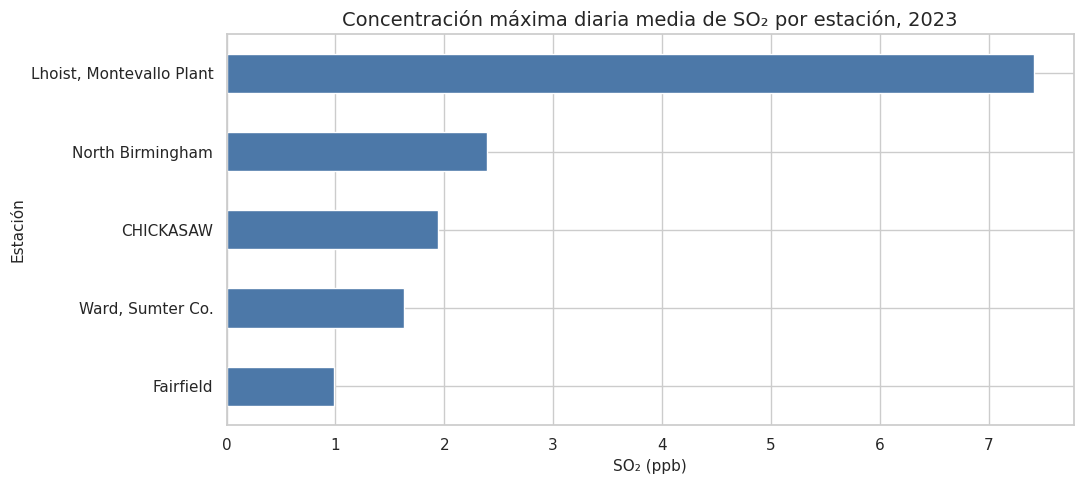

In [7]:
ax = resumen_estacion['Media'].sort_values().plot(
    kind='barh', color='#4C78A8', edgecolor='white'
)
ax.set_title('Concentración máxima diaria media de SO₂ por estación, 2023')
ax.set_xlabel('SO₂ (ppb)')
ax.set_ylabel('Estación')
plt.tight_layout()
plt.show()


## 5. Serie diaria agregada

In [8]:
diario = (
    datos.groupby('Date', as_index=False)
    .agg(
        SO2_promedio=('Daily Max SO2 Concentration', 'mean'),
        SO2_mediana=('Daily Max SO2 Concentration', 'median'),
        estaciones=('Site ID', 'nunique')
    )
    .sort_values('Date')
)

diario['dia_desde_inicio'] = (diario['Date'] - diario['Date'].min()).dt.days
diario['mes'] = diario['Date'].dt.month

print(f'Días analizados: {len(diario)}')
diario.head()


Días analizados: 365


,Date,SO2_promedio,SO2_mediana,estaciones,dia_desde_inicio,mes
0,2023-01-01,1.38,1.4,5,0,1
1,2023-01-02,1.42,0.9,5,1,1
2,2023-01-03,0.42,0.3,5,2,1
3,2023-01-04,0.60,0.6,5,3,1
4,2023-01-05,1.36,1.0,5,4,1


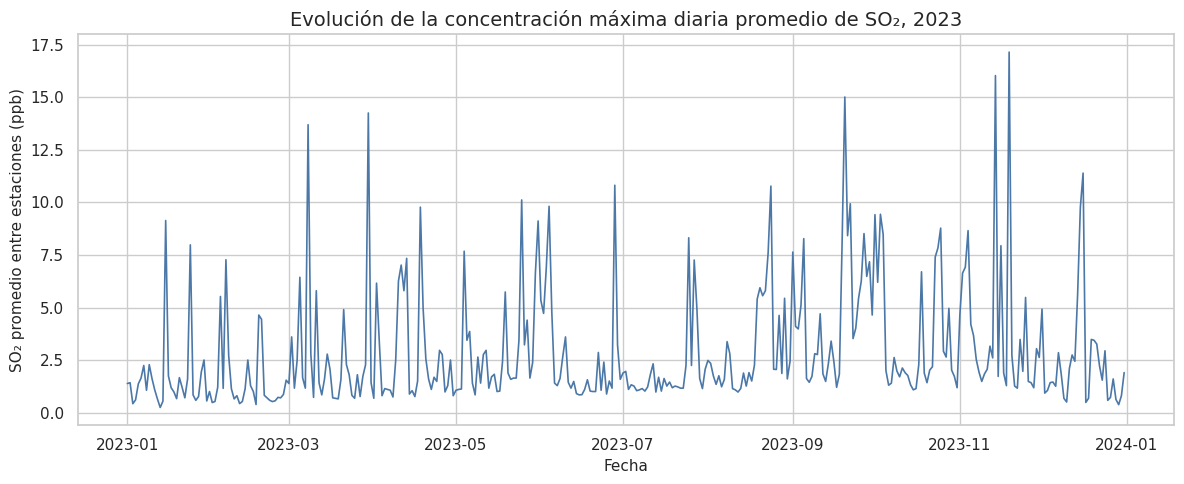

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(diario['Date'], diario['SO2_promedio'], color='#4C78A8', linewidth=1.2)
ax.set_title('Evolución de la concentración máxima diaria promedio de SO₂, 2023')
ax.set_xlabel('Fecha')
ax.set_ylabel('SO₂ promedio entre estaciones (ppb)')
plt.tight_layout()
plt.show()


In [10]:
resumen_mensual = (
    diario.assign(Mes=diario['Date'].dt.strftime('%m'))
    .groupby('Mes')['SO2_promedio']
    .agg(Media='mean', Mediana='median', Máximo='max')
)
resumen_mensual.round(3)


,Media,Mediana,Máximo
Mes,,,
01,1.662,1.18,9.140
02,1.599,0.84,7.275
03,2.772,1.66,14.260
04,2.754,1.55,9.780
05,2.994,1.88,10.120
06,2.666,1.49,10.820
07,1.965,1.26,8.320
08,2.998,2.05,10.780
09,4.871,4.06,15.020


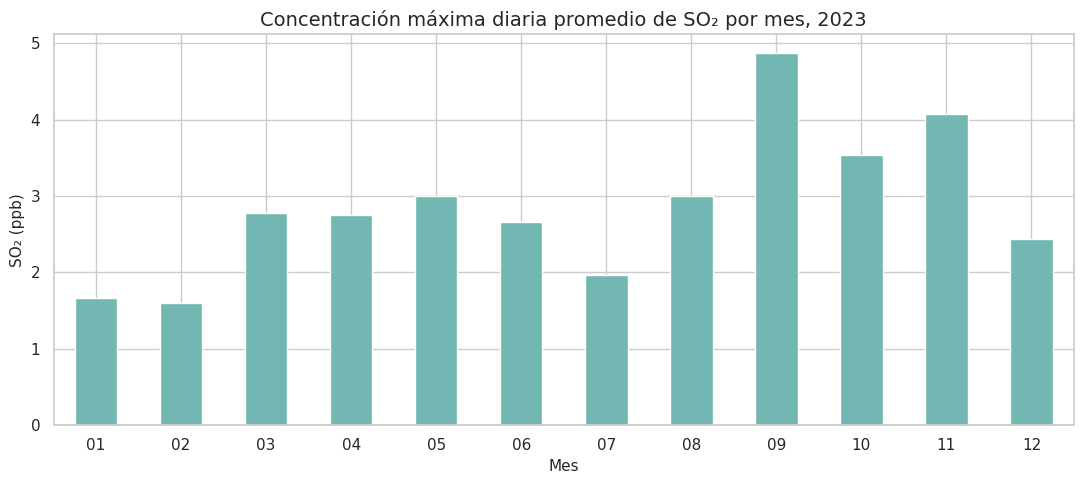

In [11]:
ax = resumen_mensual['Media'].plot(
    kind='bar', color='#72B7B2', edgecolor='white'
)
ax.set_title('Concentración máxima diaria promedio de SO₂ por mes, 2023')
ax.set_xlabel('Mes')
ax.set_ylabel('SO₂ (ppb)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 6. Regresión lineal

Se emplea el modelo:

$$\widehat{SO_2}=\beta_0+\beta_1t$$

donde $t$ representa los días transcurridos desde el 1 de enero de 2023, $\beta_0$ es el intercepto y $\beta_1$ es el cambio promedio estimado por día.


In [12]:
X = diario[['dia_desde_inicio']]
y = diario['SO2_promedio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

metricas = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Valor': [mae, rmse, r2]
})

print(f'Ecuación del modelo de entrenamiento: SO₂ = {modelo.intercept_:.4f} + ({modelo.coef_[0]:.6f} × día)')
print(f'Cambio estimado en 100 días: {modelo.coef_[0] * 100:.3f} ppb')
metricas.round(4)


Ecuación del modelo de entrenamiento: SO₂ = 2.1250 + (0.004376 × día)
Cambio estimado en 100 días: 0.438 ppb


,Métrica,Valor
0,MAE,1.8704
1,RMSE,2.5619
2,R²,0.0784


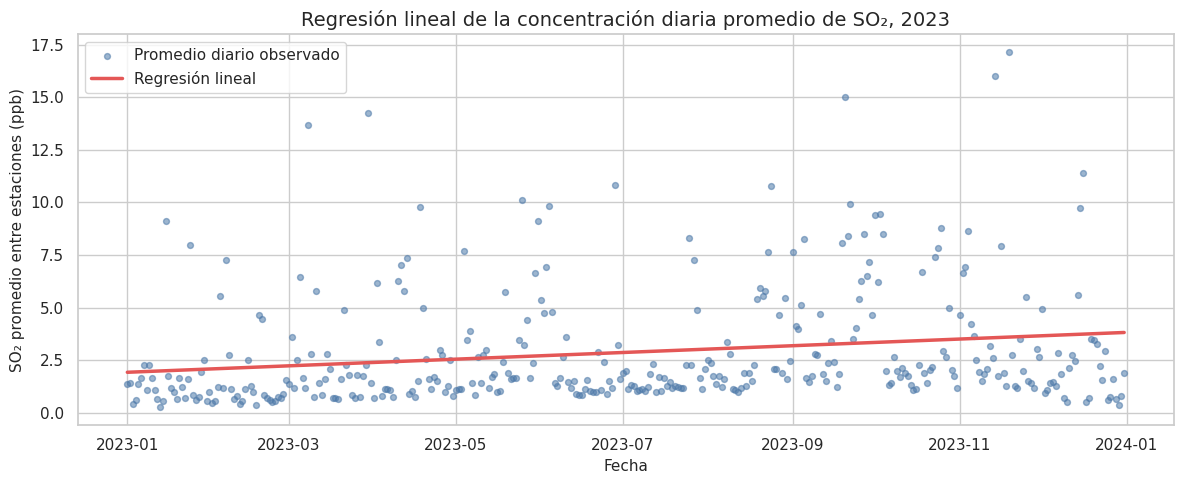

Ecuación descriptiva anual: SO₂ = 1.9161 + (0.005204 × día)
R² descriptivo con todos los datos: 0.0389


In [13]:
# Ajuste con todos los días para representar la tendencia descriptiva anual
modelo_total = LinearRegression().fit(X, y)
diario['tendencia_lineal'] = modelo_total.predict(X)

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    diario['Date'], diario['SO2_promedio'],
    s=18, alpha=0.55, color='#4C78A8', label='Promedio diario observado'
)
ax.plot(
    diario['Date'], diario['tendencia_lineal'],
    color='#E45756', linewidth=2.5, label='Regresión lineal'
)
ax.set_title('Regresión lineal de la concentración diaria promedio de SO₂, 2023')
ax.set_xlabel('Fecha')
ax.set_ylabel('SO₂ promedio entre estaciones (ppb)')
ax.legend()
plt.tight_layout()
plt.show()

print(
    f'Ecuación descriptiva anual: SO₂ = {modelo_total.intercept_:.4f} '
    f'+ ({modelo_total.coef_[0]:.6f} × día)'
)
print(f'R² descriptivo con todos los datos: {modelo_total.score(X, y):.4f}')


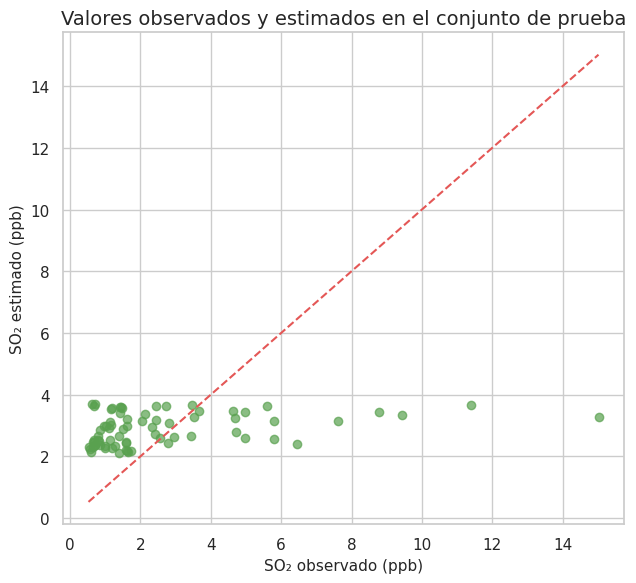

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, y_pred, alpha=0.70, color='#59A14F')
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], '--', color='#E45756')
ax.set_title('Valores observados y estimados en el conjunto de prueba')
ax.set_xlabel('SO₂ observado (ppb)')
ax.set_ylabel('SO₂ estimado (ppb)')
plt.tight_layout()
plt.show()


## 7. Resultados e interpretación

In [15]:
direccion = 'aumentó' if modelo_total.coef_[0] > 0 else 'disminuyó'
porcentaje_explicado = max(modelo_total.score(X, y), 0) * 100

print(f'''La base analizada contiene {len(datos):,} registros de 2023 procedentes de {datos['Site ID'].nunique()} estaciones.
La concentración máxima diaria promedio entre estaciones fue de {diario['SO2_promedio'].mean():.3f} ppb y el mayor promedio diario fue de {diario['SO2_promedio'].max():.3f} ppb.
La pendiente anual fue de {modelo_total.coef_[0]:.6f} ppb por día, por lo que la tendencia lineal {direccion} ligeramente durante 2023.
El R² descriptivo fue {modelo_total.score(X, y):.4f}; por tanto, la fecha explicó aproximadamente {porcentaje_explicado:.1f}% de la variación observada.
En la evaluación con datos de prueba, el MAE fue {mae:.3f} ppb y el RMSE fue {rmse:.3f} ppb.''')


La base analizada contiene 1,774 registros de 2023 procedentes de 5 estaciones.
La concentración máxima diaria promedio entre estaciones fue de 2.863 ppb y el mayor promedio diario fue de 17.160 ppb.
La pendiente anual fue de 0.005204 ppb por día, por lo que la tendencia lineal aumentó ligeramente durante 2023.
El R² descriptivo fue 0.0389; por tanto, la fecha explicó aproximadamente 3.9% de la variación observada.
En la evaluación con datos de prueba, el MAE fue 1.870 ppb y el RMSE fue 2.562 ppb.
